PROYECTO 5: Análsis de la respiración de suelo de especies invasoras

PARTE 1: DISEÑO EXPERIMENTAL:
El estudio se desarrolla bajo un enfoque cuantitativo y experimental, ya que busca medir y analizar de manera objetiva el impacto de las especies invasoras sobre la respiración del suelo. Este enfoque permite establecer relaciones causales entre la presencia de especies invasoras y los cambios en los flujos de CO₂ del suelo.

El diseño considera tres tratamientos, cada uno con cinco parcelas (plots) replicadas, y mediciones repetidas del flujo total a lo largo del tiempo para capturar la variabilidad ambiental y temporal del sistema.

Para más infromación del estudio referirse al informe adjunto.

PARTE 2: PROBABILIDADES Y ESTADÍSTICA

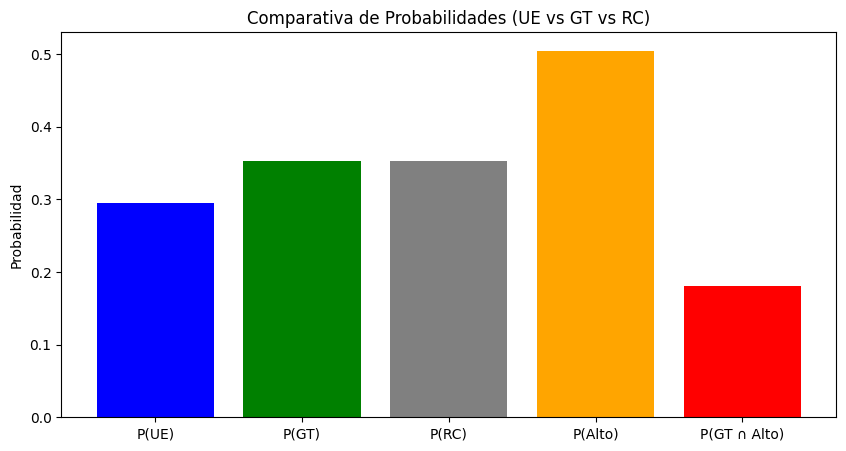

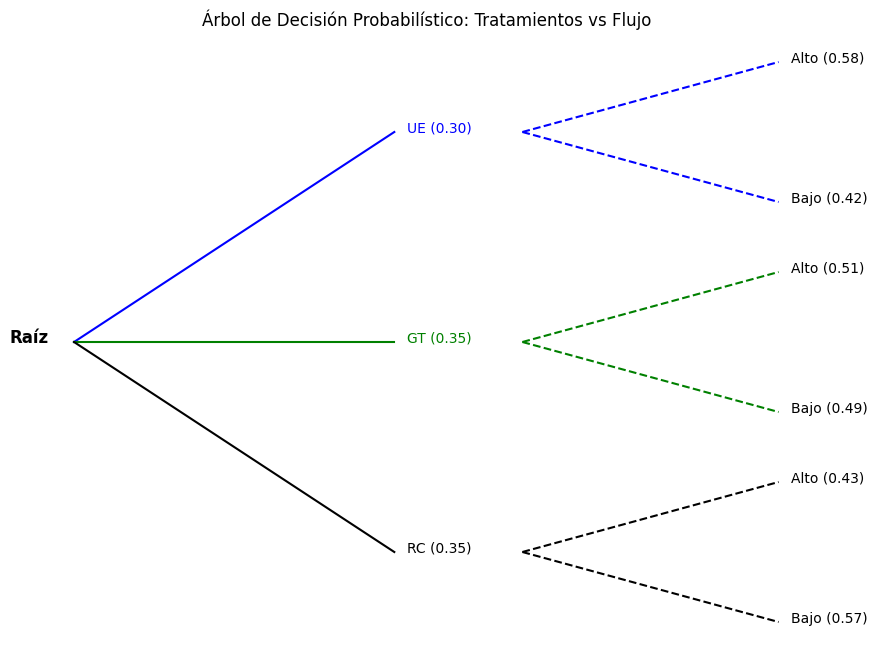

*** ANÁLISIS DE PROBABILIDADES POR TRATAMIENTO ***
Evento                    | UE     | GT     | RC    
-------------------------------------------------------
P(Tratamiento)            | 0.30   | 0.35   | 0.35
P(Alto | Tratamiento)     | 0.58   | 0.51   | 0.43
P(Trat. ∩ Alto)           | 0.17   | 0.18   | 0.15
-------------------------------------------------------
Probabilidad Global de Flujo Alto P(Alto): 0.50


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import pandas as pd
import matplotlib.pyplot as plt

### 1. Carga de datos limpios
df = pd.read_csv('flux_limpio.csv', sep=';', engine='python')
total_obs = len(df)

### 2. Definición de eventos
media_flujo = df['total'].mean()
df['flujo_alto'] = df['total'] > media_flujo

### 3. Probabilidades Marginales (Tratamientos)
p_UE = len(df[df['treat'] == 'UE']) / total_obs
p_GT = len(df[df['treat'] == 'GT']) / total_obs
p_RC = len(df[df['treat'] == 'RC']) / total_obs

p_Alto = len(df[df['flujo_alto']]) / total_obs                                  # Probabilidad de Flujo Alto (General)

### 4. Probabilidades Condicionales (Para el árbol)
p_Alto_dado_UE = len(df[(df['treat']=='UE') & (df['flujo_alto'])]) / len(df[df['treat']=='UE'])  # P(Alto | Tratamiento)
p_Alto_dado_GT = len(df[(df['treat']=='GT') & (df['flujo_alto'])]) / len(df[df['treat']=='GT'])
p_Alto_dado_RC = len(df[(df['treat']=='RC') & (df['flujo_alto'])]) / len(df[df['treat']=='RC'])

### 5. Probabilidades de Intersección y Unión (Ejemplo con GT)
p_GT_y_Alto = len(df[(df['treat'] == 'GT') & (df['flujo_alto'])]) / total_obs
p_GT_union_Alto = p_GT + p_Alto - p_GT_y_Alto

labels = ['P(UE)', 'P(GT)', 'P(RC)', 'P(Alto)', 'P(GT ∩ Alto)']
values = [p_UE, p_GT, p_RC, p_Alto, p_GT_y_Alto]

plt.figure(figsize=(10, 5))                                                     # Gráfico de barras
plt.bar(labels, values, color=['blue', 'green', 'gray', 'orange', 'red'])
plt.title('Comparativa de Probabilidades (UE vs GT vs RC)')
plt.ylabel('Probabilidad')
plt.show()


plt.figure(figsize=(10, 8))                                                     # Gráfico de árbol de pobabilidades
plt.text(0.05, 0.5, 'Raíz', fontsize=12, fontweight='bold')
plt.plot([0.1, 0.35], [0.5, 0.8], 'b-')                                         # Rama UE
plt.text(0.36, 0.8, f'UE ({p_UE:.2f})', color='blue')
plt.plot([0.45, 0.65], [0.8, 0.9], 'b--'); plt.text(0.66, 0.9, f'Alto ({p_Alto_dado_UE:.2f})')  # Sub-ramas UE
plt.plot([0.45, 0.65], [0.8, 0.7], 'b--'); plt.text(0.66, 0.7, f'Bajo ({1-p_Alto_dado_UE:.2f})')

plt.plot([0.1, 0.35], [0.5, 0.5], 'g-')                                         # Rama GT
plt.text(0.36, 0.5, f'GT ({p_GT:.2f})', color='green')
plt.plot([0.45, 0.65], [0.5, 0.6], 'g--'); plt.text(0.66, 0.6, f'Alto ({p_Alto_dado_GT:.2f})') # Sub-ramas GT
plt.plot([0.45, 0.65], [0.5, 0.4], 'g--'); plt.text(0.66, 0.4, f'Bajo ({1-p_Alto_dado_GT:.2f})')

plt.plot([0.1, 0.35], [0.5, 0.2], 'k-')                                         # Rama RC
plt.text(0.36, 0.2, f'RC ({p_RC:.2f})', color='black')
plt.plot([0.45, 0.65], [0.2, 0.3], 'k--'); plt.text(0.66, 0.3, f'Alto ({p_Alto_dado_RC:.2f})') # Sub-ramas RC
plt.plot([0.45, 0.65], [0.2, 0.1], 'k--'); plt.text(0.66, 0.1, f'Bajo ({1-p_Alto_dado_RC:.2f})')

plt.title('Árbol de Decisión Probabilístico: Tratamientos vs Flujo')
plt.axis('off')
plt.show()

### 6. Resultados
print("*** ANÁLISIS DE PROBABILIDADES POR TRATAMIENTO ***")
print(f"{'Evento':<25} | {'UE':<6} | {'GT':<6} | {'RC':<6}")
print("-" * 55)

print(f"{'P(Tratamiento)':<25} | {p_UE:.2f}   | {p_GT:.2f}   | {p_RC:.2f}")     # Probabilidades Marginales
print(f"{'P(Alto | Tratamiento)':<25} | {p_Alto_dado_UE:.2f}   | {p_Alto_dado_GT:.2f}   | {p_Alto_dado_RC:.2f}")  # Probabilidades Condicionales (Éxito de flujo alto dentro de cada grupo)

p_UE_y_Alto = len(df[(df['treat'] == 'UE') & (df['flujo_alto'])]) / total_obs   # Intersecciones (Probabilidad respecto al total de la muestra)
p_RC_y_Alto = len(df[(df['treat'] == 'RC') & (df['flujo_alto'])]) / total_obs

print(f"{'P(Trat. ∩ Alto)':<25} | {p_UE_y_Alto:.2f}   | {p_GT_y_Alto:.2f}   | {p_RC_y_Alto:.2f}")

print("-" * 55)
print(f"Probabilidad Global de Flujo Alto P(Alto): {p_Alto:.2f}")

PARTE 3: DISTRIBUCIÓN DE PROBABILIDADES

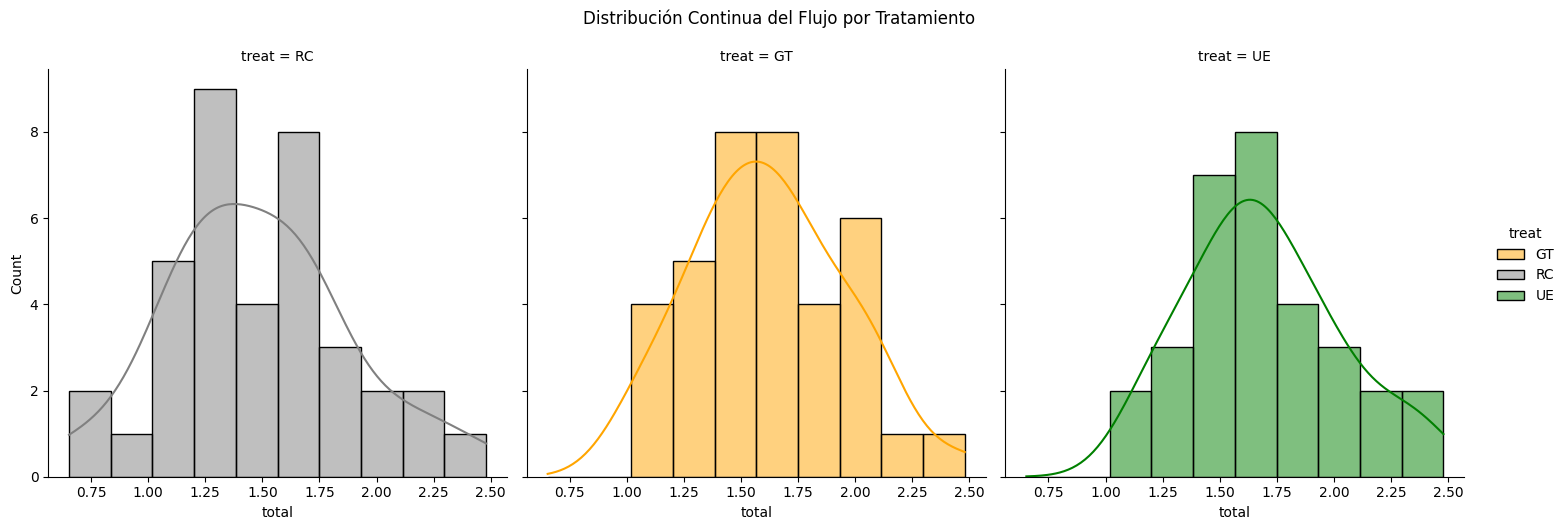

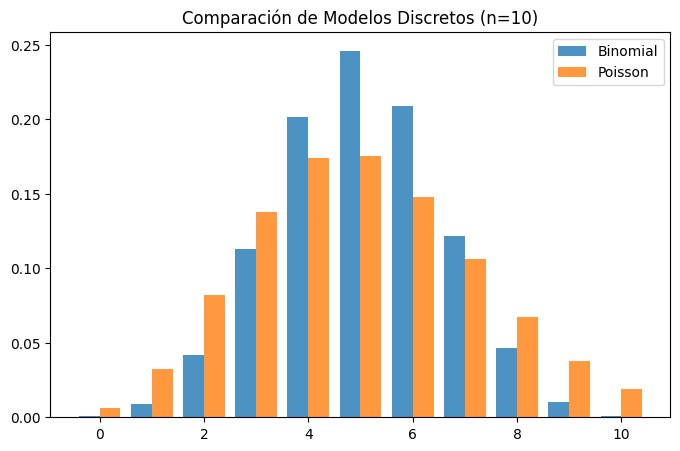

In [ ]:
import scipy.stats as stats

### 1. Ajuste a distribucón

##### 1. A. CONTINUA (Normal): Para la variable 'total'.
mu, sigma = df['total'].mean(), df['total'].std()                               # Fenómenos naturales continuos con tendencia central.
prob_norm = 1 - stats.norm.cdf(40, mu, sigma)                                   # P(Total > 40)

##### 1. B. DISCRETA (Binomial): Éxitos en n ensayos.
n, p = 10, p_Alto                                                               # Probabilidad de obtener 'k' flujos altos en una muestra de n=10
prob_binom = stats.binom.pmf(6, n, p)                                           # P(X=6)

##### 1. C. DISCRETA (Poisson): Eventos por unidad.
lam = n * p                                                                     # Tasa de ocurrencia: Se usa cuando conocemos la tasa promedio (lambda) de ocurrencia.
prob_poisson = stats.poisson.pmf(5, lam)                                        # P(X=5)


### 2. Visualización
orden = ['RC', 'GT', 'UE']                                                      # Facetas por Tratamiento
colores = {'RC': 'gray', 'GT': 'orange', 'UE': 'green'}
g = sns.displot(data=df, x='total', col='treat', hue='treat',
                col_order=orden, palette=colores, kde=True)
g.fig.suptitle('Distribución Continua del Flujo por Tratamiento', y=1.05)
plt.savefig('facetas.png')

plt.figure(figsize=(8, 5))                                                       # Gráfico de barras
k = np.arange(0, 11)
plt.bar(k-0.2, stats.binom.pmf(k, n, p), width=0.4, label='Binomial', alpha=0.8)
plt.bar(k+0.2, stats.poisson.pmf(k, lam), width=0.4, label='Poisson', alpha=0.8)
plt.title('Comparación de Modelos Discretos (n=10)')
plt.legend()
plt.savefig('discretas.png')

PARTE 4: DISTRIBUCIÓN MUESTRAL Y TEOREMA DEL LÍMITE CENTRAL

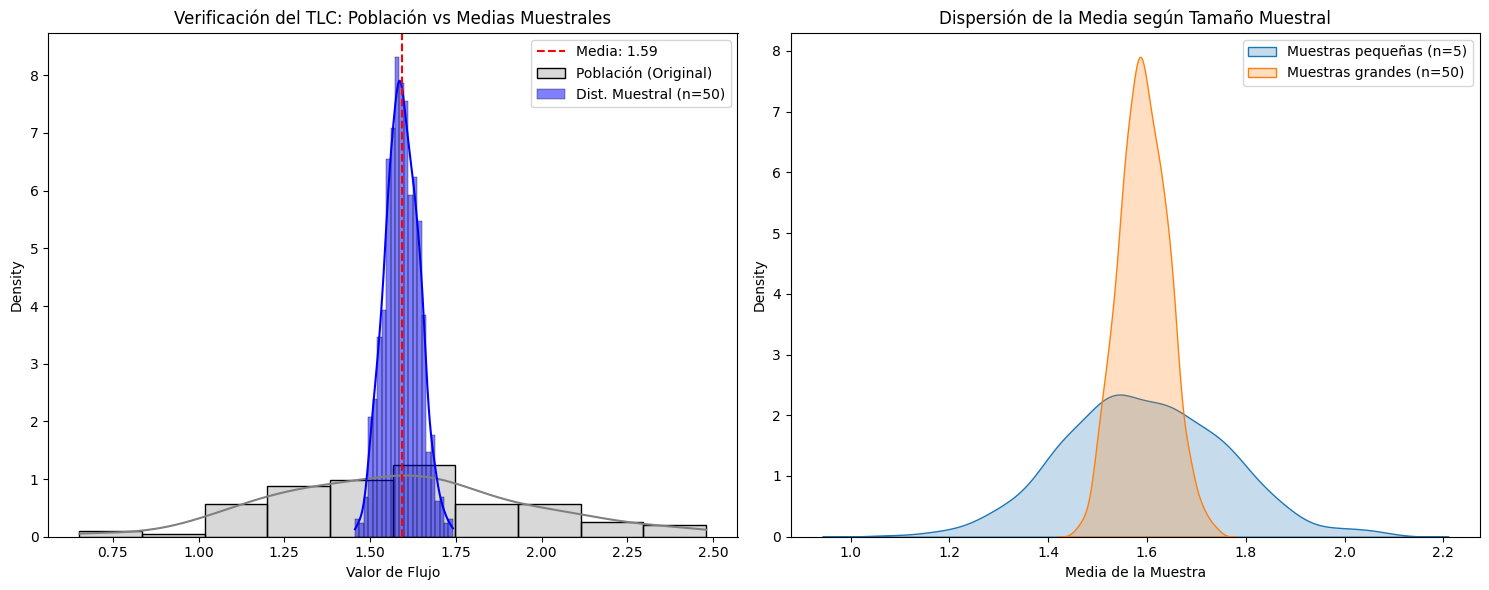

*** Análisis de Dispersión ***
Desviación Estándar Poblacional: 0.3655
Error Estándar (n=5): 0.1625
Error Estándar (n=50): 0.0488


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#### 1. Preparación de la "Población"
poblacion = df['total']
media_poblacional = poblacion.mean()

### 2. Generación de Distribuciones Muestrales de la Media
def generar_distribucion_muestral(datos, n_tamaño, iteraciones=1000):           # Se compara qué pasa con muestras pequeñas (n=5) vs grandes (n=50)
    return [datos.sample(n_tamaño, replace=True).mean() for _ in range(iteraciones)]

medias_n5 = generar_distribucion_muestral(poblacion, 5)
medias_n50 = generar_distribucion_muestral(poblacion, 50)

### 3. VERIFICACIÓN EMPÍRICA DEL TLC Y ANÁLISIS DE DISPERSIÓN
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)                                                            # Subplot 1: Distribución Poblacional vs Distribución Muestral
sns.histplot(poblacion, kde=True, color='gray', label='Población (Original)', stat="density", alpha=0.3)
sns.histplot(medias_n50, kde=True, color='blue', label='Dist. Muestral (n=50)', stat="density")
plt.axvline(media_poblacional, color='red', linestyle='--', label=f'Media: {media_poblacional:.2f}')
plt.title('Verificación del TLC: Población vs Medias Muestrales')
plt.xlabel('Valor de Flujo')
plt.legend()

plt.subplot(1, 2, 2)                                                            # Subplot 2: Dispersión según tamaño muestral (Error Estándar)
sns.kdeplot(medias_n5, label='Muestras pequeñas (n=5)', fill=True)
sns.kdeplot(medias_n50, label='Muestras grandes (n=50)', fill=True)
plt.title('Dispersión de la Media según Tamaño Muestral')
plt.xlabel('Media de la Muestra')
plt.legend()

plt.tight_layout()
plt.show()

### 4. Resultados Estadísticos (Justificación para la tarea)
print(f"*** Análisis de Dispersión ***")
print(f"Desviación Estándar Poblacional: {poblacion.std():.4f}")
print(f"Error Estándar (n=5): {np.std(medias_n5):.4f}")
print(f"Error Estándar (n=50): {np.std(medias_n50):.4f}")

PARTE 5:INFERENCIA E INTERVALOS DE CONFIANZA

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

#### 1. Preparación de datos (Solo se comparará UE vs RC)
ue_data = df[df['treat'] == 'UE']['total']
rc_data = df[df['treat'] == 'RC']['total']

def analizar_intervalos(data, nombre):
    niveles = [0.90, 0.95, 0.99]
    print(f"\n*** Análisis para Tratamiento: {nombre} ***")
    for conf in niveles:
        media = np.mean(data)
        sem = stats.sem(data)                                                   # Error estándar de la media
        ic = stats.t.interval(conf, len(data)-1, loc=media, scale=sem)          # Cálculo del intervalo usando la distribución t de Student
        ancho = ic[1] - ic[0]
        print(f"Confianza {int(conf*100)}%: [{ic[0]:.2f}, {ic[1]:.2f}] | Ancho: {ancho:.2f}")

#### 2. Cálculo de Intervalos
analizar_intervalos(ue_data, "UE")
analizar_intervalos(rc_data, "RC")

### 3. Evaluación del Impacto del Tamaño Muestral (n)

print("\n*** Impacto del Tamaño Muestral (n) en el Error ***")                  # Simulamos cómo varía el ancho del IC al aumentar el número de muestras
for n in [20, 100, 500]:
    sim_data = np.random.normal(38, 8, n)
    ic = stats.t.interval(0.95, n-1, loc=np.mean(sim_data), scale=stats.sem(sim_data))
    print(f"Para n={n:3d}: Ancho del Intervalo = {(ic[1]-ic[0]):.2f}")


*** Análisis para Tratamiento: UE ***
Confianza 90%: [1.59, 1.79] | Ancho: 0.20
Confianza 95%: [1.57, 1.81] | Ancho: 0.24
Confianza 99%: [1.53, 1.86] | Ancho: 0.33

*** Análisis para Tratamiento: RC ***
Confianza 90%: [1.37, 1.59] | Ancho: 0.22
Confianza 95%: [1.35, 1.62] | Ancho: 0.27
Confianza 99%: [1.30, 1.66] | Ancho: 0.36

*** Impacto del Tamaño Muestral (n) en el Error ***
Para n= 20: Ancho del Intervalo = 7.33
Para n=100: Ancho del Intervalo = 3.18
Para n=500: Ancho del Intervalo = 1.47


PARTE 6: TEST DE SIGNIFICANCIA

In [ ]:
import pandas as pd
from scipy import stats

### 1. ANOVA de una vía para comparar entre tratamientos
# H0: µ_RC = µ_GT = µ_UE (Todas las medias son iguales)
# H1: Al menos una media es diferente
f_stat, p_valor_anova = stats.f_oneway(
    df_final[df_final['treat'] == 'UE']['total'],
    df_final[df_final['treat'] == 'GT']['total'],
    df_final[df_final['treat'] == 'RC']['total']
)

print(f"*** RESULTADO ANOVA GLOBAL ***")
print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor-p: {p_valor_anova:.4e}")

### 2. Pruebas de comparación por pares (Post-hoc)

alpha_original = 0.05                                                           # Se usa corrección de Bonferroni para mantener el nivel de significancia global en 0.05
comparaciones = [('UE', 'RC'), ('GT', 'RC'), ('UE', 'GT')]
alpha_adj = alpha_original / len(comparaciones)                                 # Nuevo umbral: 0.0166

print(f"\n*** COMPARACIONES POR PARES (Alpha adj: {alpha_adj:.4f}) ***")
for g1, g2 in comparaciones:
    t_stat, p_v = stats.ttest_ind(df_final[df_final['treat'] == g1]['total'],
                                   df_final[df_final['treat'] == g2]['total'])
    estado = "SIGNIFICATIVO" if p_v < alpha_adj else "NO SIGNIFICATIVO"
    print(f"{g1} vs {g2}: p-valor = {p_v:.4e} | {estado}")

*** RESULTADO ANOVA GLOBAL ***
Estadístico F: 3.1145
Valor-p: 4.8648e-02

*** COMPARACIONES POR PARES (Alpha adj: 0.0167) ***
UE vs RC: p-valor = 2.2018e-02 | NO SIGNIFICATIVO
GT vs RC: p-valor = 1.1098e-01 | NO SIGNIFICATIVO
UE vs GT: p-valor = 3.6825e-01 | NO SIGNIFICATIVO
